# Proyecto del Día 12 - Análisis y Clasificación de Clientes

Bienvenido al **Proyecto del Día 12**. Lee atentamente la consigna *¡y a programar!*


### Título: Análisis y Clasificación de Clientes para Campañas de Marketing

En este proyecto, vas a aplicar técnicas avanzadas de análisis de datos para resolver un problema de clasificación de clientes en un conjunto de datos simulado.

El objetivo es identificar distintos segmentos de clientes basados en sus comportamientos de compra y características demográficas para diseñar campañas de marketing más efectivas.


### Descripción del Proyecto

Este proyecto tiene como objetivo utilizar técnicas de análisis de datos y aprendizaje automático para identificar diferentes segmentos de clientes basados en sus comportamientos de compra y características demográficas. Esto te permitirá desarrollar estrategias de marketing dirigidas y personalizadas. Vas a aplicar métodos de preprocesamiento de datos, reducción de dimensiones, y técnicas de clustering para analizar un conjunto de datos simulado de clientes.


### Datos

Vas a utilizar un dataset simulado llamado `datos_clientes.csv` que te descargarás en los recursos de esta lección, y que contiene información demográfica y de comportamiento de compra de clientes, como la edad, los ingresos anuales, la puntuación de gasto y la categoría de producto favorito.


### Consigna del Proyecto

1. **Preprocesamiento de Datos**: Cargar, limpiar y preparar el dataset para el análisis. Esto incluye la normalización de los datos para asegurar que las técnicas de reducción de dimensiones y clustering funcionen correctamente.
2. **Reducción de Dimensiones**: Utilizar **PCA** y **SVD** para reducir la cantidad de variables y destacar las características más importantes que influyen en el comportamiento del cliente.
3. **Clustering**: Implementar **K-Means** y **Clustering Jerárquico** para segmentar los clientes en grupos basados en similitudes en sus datos. Esto ayudará a identificar patrones y tendencias entre diferentes tipos de clientes.
4. **Visualización de Datos**: Crear visualizaciones para interpretar los resultados de las técnicas de reducción de dimensiones y clustering. Esto incluye la creación de **gráficos de dispersión** para los resultados de PCA y la visualización de **dendrogramas** para el Clustering Jerárquico.
5. **Interpretación y Estrategias de Marketing**: Analizar los clusters obtenidos y desarrollar propuestas de estrategias de marketing específicas para cada segmento de clientes. Deberás justificar tus estrategias basándote en las características y comportamientos de los grupos identificados.

¡Mucha suerte, y que te diviertas!

## Análisis y Clasificación de Clientes para Campañas de Marketing

### 1. Preprocesamiento de Datos

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

In [4]:
df = pd.read_csv(r'C:\Users\Pablo\Documents\Carpeta Github Aprendizaje\Courses_DataScience_ML-DL-Simulink\Python-DS-ML_UDEMYCourse\Día12-MachineLearning-p2\customer_data.csv')

In [5]:
df.head(5)

,ID Cliente,Edad,Ingresos Anuales (k$),Puntuación de Gasto (1-100),Categoría de Producto Favorito
0,1,56,89,47,Libros
1,2,69,91,86,Hogar
2,3,46,46,23,Electrónica
3,4,32,28,66,Libros
4,5,60,81,27,Electrónica


In [32]:
df['Categoría de Producto Favorito'].unique()

array(['Libros', 'Hogar', 'Electrónica', 'Alimentos', 'Ropa'],
      dtype=object)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   ID Cliente                      200 non-null    int64 
 1   Edad                            200 non-null    int64 
 2   Ingresos Anuales (k$)           200 non-null    int64 
 3   Puntuación de Gasto (1-100)     200 non-null    int64 
 4   Categoría de Producto Favorito  200 non-null    object
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [46]:
df.columns

Index(['ID Cliente', 'Edad', 'Ingresos Anuales (k$)',
       'Puntuación de Gasto (1-100)', 'Categoría de Producto Favorito'],
      dtype='object')

In [58]:
escalador = MinMaxScaler()
X_centro = escalador.fit_transform(df[['Edad', 'Ingresos Anuales (k$)',
       'Puntuación de Gasto (1-100)']])
X_centro

array([[0.74509804, 0.6969697 , 0.46938776],
       [1.        , 0.71717172, 0.86734694],
       [0.54901961, 0.26262626, 0.2244898 ],
       [0.2745098 , 0.08080808, 0.66326531],
       [0.82352941, 0.61616162, 0.26530612],
       [0.1372549 , 0.36363636, 0.01020408],
       [0.39215686, 0.96969697, 0.90816327],
       [0.74509804, 0.50505051, 0.16326531],
       [0.35294118, 0.43434343, 0.32653061],
       [0.43137255, 0.23232323, 0.08163265],
       [0.19607843, 0.78787879, 0.42857143],
       [0.19607843, 0.58585859, 0.47959184],
       [0.45098039, 0.31313131, 0.3877551 ],
       [0.68627451, 0.95959596, 0.93877551],
       [0.76470588, 0.87878788, 0.41836735],
       [0.45098039, 0.51515152, 0.25510204],
       [0.03921569, 0.61616162, 1.        ],
       [0.41176471, 0.57575758, 0.5       ],
       [0.01960784, 0.51515152, 0.24489796],
       [0.45098039, 0.11111111, 0.23469388],
       [0.84313725, 0.38383838, 0.12244898],
       [0.56862745, 0.01010101, 0.60204082],
       [0.

### 2. Reducción de Dimensiones: PCA y SVD

In [59]:
modelo = PCA(n_components = 2)
pca = modelo.fit_transform(X_centro)

In [60]:
U, sigma, VT = np.linalg.svd(X_centro)
k = 2
X_transformado = U[:,:k] * sigma[:k]

### 3. Clustering: K-Means y Clustering Jerárquico

In [61]:
modelo_kmeans = KMeans(n_clusters = 3, random_state=42)
modelo_kmeans.fit(X_centro)
kmenas_cluster = modelo_kmeans.fit_predict(X_centro)

D:\Programas\ANACONDA\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Programas\ANACONDA\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [62]:
linked = linkage(X_centro, method='ward')
linked

array([[1.51000000e+02, 1.52000000e+02, 0.00000000e+00, 2.00000000e+00],
       [1.49000000e+02, 1.94000000e+02, 1.02040816e-02, 2.00000000e+00],
       [4.60000000e+01, 1.91000000e+02, 2.27711118e-02, 2.00000000e+00],
       [3.00000000e+00, 9.90000000e+01, 3.06122449e-02, 2.00000000e+00],
       [1.40000000e+02, 1.99000000e+02, 4.04956844e-02, 2.00000000e+00],
       [1.57000000e+02, 1.92000000e+02, 4.73270609e-02, 2.00000000e+00],
       [1.53000000e+02, 1.82000000e+02, 5.07642590e-02, 2.00000000e+00],
       [7.00000000e+00, 1.48000000e+02, 5.10204082e-02, 2.00000000e+00],
       [1.20000000e+01, 1.29000000e+02, 5.55839902e-02, 2.00000000e+00],
       [4.30000000e+01, 4.50000000e+01, 5.74967214e-02, 2.00000000e+00],
       [2.00000000e+00, 1.87000000e+02, 5.78940478e-02, 2.00000000e+00],
       [4.80000000e+01, 6.80000000e+01, 5.90581888e-02, 2.00000000e+00],
       [1.18000000e+02, 1.33000000e+02, 6.40895161e-02, 2.00000000e+00],
       [1.00000000e+00, 1.11000000e+02, 6.42876789e

### 4. Visualización de Datos

<Axes: >

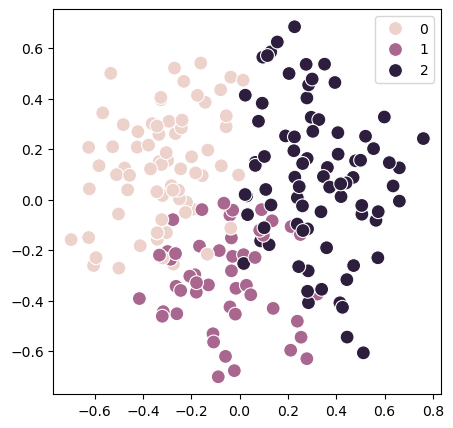

In [63]:
plt.figure(figsize=(5,5))
sns.scatterplot(x=pca[:,0], y=pca[:,1], hue=kmenas_cluster, s=100)

Text(0, 0.5, 'Distancia')

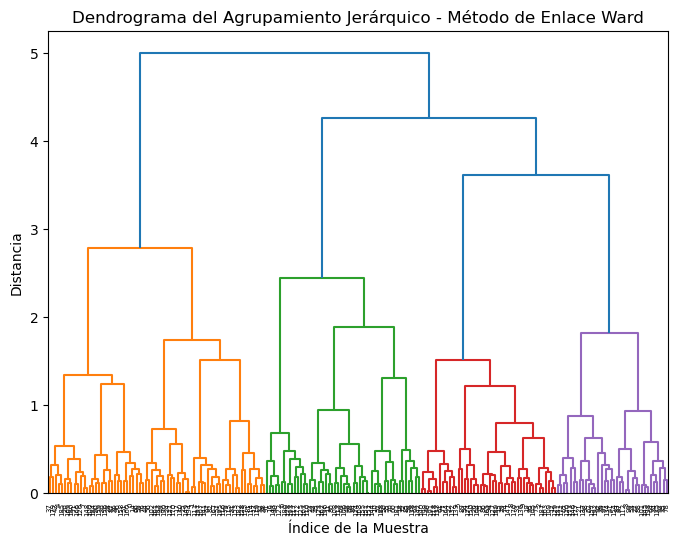

In [64]:
plt.figure(figsize=(8,6))
dendrogram(linked)
plt.title('Dendrograma del Agrupamiento Jerárquico - Método de Enlace Ward')
plt.xlabel('Índice de la Muestra')
plt.ylabel('Distancia')

### 5. Interpretación y Estrategias de Marketing basadas en los Clusters

In [68]:
cluster_info = pd.DataFrame({
    'Cluster': kmenas_cluster,
    'Edad' : df['Edad'],
    'Ingresos' : df['Ingresos Anuales (k$)'],
    'Gasto' : df['Puntuación de Gasto (1-100)']
})

for cluster in cluster_info['Cluster'].unique():
    cluster_data = cluster_info[cluster_info['Cluster'] == cluster]
    print(f'Cluster {cluster}:')
    print(f'Edad Media: {cluster_data['Edad'].mean():0.2f}:')
    print(f'Ingresos: {cluster_data['Ingresos'].mean():0.2f}:')
    print(f'Gastos:  {cluster_data['Gasto'].mean():0.2f}:')

Cluster 2:
Edad Media: 49.67:
Ingresos: 97.33:
Gastos:  62.00:
Cluster 0:
Edad Media: 42.97:
Ingresos: 52.51:
Gastos:  20.17:
Cluster 1:
Edad Media: 34.06:
Ingresos: 49.08:
Gastos:  72.20:


In [ ]:
# Redacta una propuesta de estrategia de marketing para los diferentes clusters